## **데이터 분석 준비**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

%matplotlib inline
%config InlineBackend.figure_format = 'retina' # 그래프 고해상도 출력 옵션

In [3]:
# euc-kr(Extended Unix Code-KR)는 한국어 문자를 컴퓨터에서 처리하기 위한 문자 인코딩 방식 중 하나입니다.
crime_raw_data = pd.read_csv('.\\seoul_crime_2021.csv', encoding='euc-kr')
crime_raw_data.head()

,구분,죄종,발생검거,건수,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,중부,살인,발생,4,NaN,NaN,NaN,NaN,NaN
1,중부,살인,검거,4,NaN,NaN,NaN,NaN,NaN
2,중부,강도,발생,3,NaN,NaN,NaN,NaN,NaN
3,중부,강도,검거,3,NaN,NaN,NaN,NaN,NaN
4,중부,"강간,추행",발생,109,NaN,NaN,NaN,NaN,NaN


## **데이터 전처리**

### **데이터 클리닝**

In [4]:
# 데이터의 전반적인 요약된 정보 확인
crime_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   구분          310 non-null    object 
 1   죄종          310 non-null    object 
 2   발생검거        310 non-null    object 
 3   건수          310 non-null    int64  
 4   Unnamed: 4  0 non-null      float64
 5   Unnamed: 5  0 non-null      float64
 6   Unnamed: 6  0 non-null      float64
 7   Unnamed: 7  0 non-null      float64
 8   Unnamed: 8  0 non-null      float64
dtypes: float64(5), int64(1), object(3)
memory usage: 21.9+ KB


In [5]:
# 죄종 컬럼에서 한 번이라도 등장한 값이 어떤게 있는지 확인
crime_raw_data['죄종'].unique()

array(['살인', '강도', '강간,추행', '절도', '폭력', '강간'], dtype=object)

In [6]:
# '성범죄'로 데이터 통일
crime_raw_data['죄종'] = crime_raw_data['죄종'].replace(['강간,추행', '강간'], '성범죄')

# 데이터 다시 확인
crime_raw_data['죄종'].unique()

array(['살인', '강도', '성범죄', '절도', '폭력'], dtype=object)

### **NaN 값 데이터 삭제**
- dropna(): NaN 값이 있는 경우 데이터 삭제
- axis 1 or 0
    - 1은 열을 삭제
    - 0은 행을 삭제
- inplace=True
    - 원본 데이터프레임에 바뀐 내용을 저장

In [7]:
# NaN 값이 있는 열 삭제
crime_raw_data.dropna(axis=1, inplace=True)

In [8]:
# 데이터 클리닝 후 요약 정보 다시 확인
crime_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   구분      310 non-null    object
 1   죄종      310 non-null    object
 2   발생검거    310 non-null    object
 3   건수      310 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 9.8+ KB


In [9]:
# 데이터 프레임 확인
crime_raw_data.head()

,구분,죄종,발생검거,건수
0,중부,살인,발생,4
1,중부,살인,검거,4
2,중부,강도,발생,3
3,중부,강도,검거,3
4,중부,성범죄,발생,109


### **Pivot Table**

In [10]:
# 경찰서별 죄종, 발생검거 각 건수
crime_station = pd.pivot_table(
    data=crime_raw_data,
    index='구분',
    columns=['죄종', '발생검거'],
)
crime_station.head()

건수                                                             
죄종      강도         살인         성범죄            절도              폭력        
발생검거    검거    발생   검거   발생     검거     발생     검거      발생      검거      발생
구분                                                                     
강남    11.0  13.0  6.0  8.0  325.0  428.0  737.0  1517.0  1699.0  1961.0
강동     6.0   6.0  3.0  3.0  103.0  124.0  889.0  1612.0  1461.0  1713.0
강북     1.0   1.0  4.0  4.0  115.0  136.0  537.0   777.0  1255.0  1383.0
강서     3.0   3.0  7.0  9.0  188.0  246.0  921.0  1540.0  1925.0  2098.0
관악     6.0   7.0  4.0  8.0  269.0  321.0  929.0  1860.0  1926.0  2248.0

In [11]:
# 3줄의 컬럼 중, '건수' 컬럼 삭제
crime_station.columns = crime_station.columns.droplevel(0)

In [12]:
# 5대 범죄의 '검거', '발생' 컬럼
crime_station.columns

MultiIndex([( '강도', '검거'),
            ( '강도', '발생'),
            ( '살인', '검거'),
            ( '살인', '발생'),
            ('성범죄', '검거'),
            ('성범죄', '발생'),
            ( '절도', '검거'),
            ( '절도', '발생'),
            ( '폭력', '검거'),
            ( '폭력', '발생')],
           names=['죄종', '발생검거'])

In [13]:
# 발생한 강도 사건 중, 검거한 건수 상위 5개
crime_station['강도', '검거'].sort_values(ascending=False).head()

구분
수서     12.0
영등포    11.0
강남     11.0
동대문     8.0
중랑      7.0
Name: (강도, 검거), dtype: float64

In [14]:
# 살인이 발생한 건수 상위 5개
crime_station['살인', '발생'].sort_values(ascending=False).head()

구분
서초     9.0
강서     9.0
관악     8.0
영등포    8.0
강남     8.0
Name: (살인, 발생), dtype: float64

In [15]:
# 그러면, 강남경찰서에서 발생한 강도 사건 건수
crime_station.loc['강남', ('강도', '발생')]

13.0

In [16]:
# 다중 컬럼 정리
tmp = crime_station.columns.get_level_values(0) + crime_station.columns.get_level_values(1)
tmp

Index(['강도검거', '강도발생', '살인검거', '살인발생', '성범죄검거', '성범죄발생', '절도검거', '절도발생',
       '폭력검거', '폭력발생'],
      dtype='object')

In [17]:
# 기존 컬럼 길이와 새로운 컬럼 길이가 같은지 확인
len(crime_station.columns), len(tmp)

(10, 10)

In [18]:
# 기존 컬럼을 새로운 컬럼으로 덮어 씌움
crime_station.columns = tmp

In [19]:
# 다중컬럼을 단일컬럼으로 정리한 내용 확인
crime_station.head()

,강도검거,강도발생,살인검거,살인발생,성범죄검거,성범죄발생,절도검거,절도발생,폭력검거,폭력발생
구분,,,,,,,,,,
강남,11.0,13.0,6.0,8.0,325.0,428.0,737.0,1517.0,1699.0,1961.0
강동,6.0,6.0,3.0,3.0,103.0,124.0,889.0,1612.0,1461.0,1713.0
강북,1.0,1.0,4.0,4.0,115.0,136.0,537.0,777.0,1255.0,1383.0
강서,3.0,3.0,7.0,9.0,188.0,246.0,921.0,1540.0,1925.0,2098.0
관악,6.0,7.0,4.0,8.0,269.0,321.0,929.0,1860.0,1926.0,2248.0


### **경찰서별 담당 행정 구역 컬럼 생성**

In [20]:
crime_station.index

Index(['강남', '강동', '강북', '강서', '관악', '광진', '구로', '금천', '남대문', '노원', '도봉',
       '동대문', '동작', '마포', '방배', '서대문', '서부', '서초', '성동', '성북', '송파', '수서',
       '양천', '영등포', '용산', '은평', '종로', '종암', '중랑', '중부', '혜화'],
      dtype='object', name='구분')

In [21]:
real_gu = {
    '종로구':['종로', '혜화'], '중구':['남대문', '중부'],
    '용산구':['용산'], '성동구':['성동'],
    '광진구':['광진'], '동대문구':['동대문'],
    '중랑구':['중랑'], '성북구':['성북', '종암'],
    '강북구':['강북'], '도봉구':['도봉'],
    '노원구':['노원'], '은평구':['서부', '은평'],
    '서대문구':['서대문'], '마포구':['마포'],
    '양천구':['양천'], '강서구':['강서'],
    '구로구':['구로'], '금천구':['금천'],
    '영등포구':['영등포'], '동작구':['동작'],
    '관악구':['관악'], '서초구':['방배', '서초'],
    '강남구':['강남', '수서'], '송파구':['송파'],
    '강동구':['강동']
}

In [22]:
tmp_gu = []

for station in crime_station.index:
    for gu_name, station_name in real_gu.items():
        if station in station_name:
            tmp_gu.append(gu_name)

In [23]:
# 인덱스와 구 컬럼의 길이가 같은지 확인
len(crime_station.index), len(tmp_gu)

(31, 31)

In [24]:
# 길이가 같다면, 구 컬럼 추가
crime_station['구'] = tmp_gu

In [25]:
# 구별 범죄 건수 집계 데이터 프레임
crime_gu = crime_station.pivot_table(index='구', aggfunc='sum')
crime_gu.head()

,강도검거,강도발생,살인검거,살인발생,성범죄검거,성범죄발생,절도검거,절도발생,폭력검거,폭력발생
구,,,,,,,,,,
강남구,23.0,25.0,11.0,12.0,454.0,578.0,1160.0,2372.0,2749.0,3159.0
강동구,6.0,6.0,3.0,3.0,103.0,124.0,889.0,1612.0,1461.0,1713.0
강북구,1.0,1.0,4.0,4.0,115.0,136.0,537.0,777.0,1255.0,1383.0
강서구,3.0,3.0,7.0,9.0,188.0,246.0,921.0,1540.0,1925.0,2098.0
관악구,6.0,7.0,4.0,8.0,269.0,321.0,929.0,1860.0,1926.0,2248.0


In [26]:
# 살인이 많이 일어난 구 상위 10개
crime_gu['살인발생'].sort_values(ascending=False).head(10)

구
강남구     12.0
서초구      9.0
강서구      9.0
관악구      8.0
영등포구     8.0
금천구      7.0
중구       6.0
노원구      6.0
종로구      6.0
광진구      5.0
Name: 살인발생, dtype: float64

In [27]:
# 절도 범죄가 가장 적게 일어난 구 상위 5개
crime_gu['절도발생'].sort_values().head()

구
도봉구    772.0
강북구    777.0
성북구    895.0
성동구    905.0
용산구    945.0
Name: 절도발생, dtype: float64

### **검거율 컬럼 생성**

$$
\text{검거율} = \frac{\text{범죄검거}}{\text{범죄발생}}
$$

In [28]:
(crime_gu['절도검거'] / crime_gu['절도발생']) * 100

구
강남구     48.903879
강동구     55.148883
강북구     69.111969
강서구     59.805195
관악구     49.946237
광진구     53.323904
구로구     55.395683
금천구     51.332675
노원구     48.052902
도봉구     48.704663
동대문구    53.145161
동작구     59.787422
마포구     48.344371
서대문구    54.722493
서초구     45.974717
성동구     54.917127
성북구     52.960894
송파구     49.160079
양천구     51.890289
영등포구    48.539720
용산구     51.216931
은평구     57.935393
종로구     46.709917
중구      57.779515
중랑구     59.685490
dtype: float64

In [29]:
arrest_col = ['강도검거', '살인검거', '성범죄검거', '절도검거', '폭력검거']
occur_col = ['강도발생', '살인발생', '성범죄발생', '절도발생', '폭력발생']
arrest_rate = ['강도검거율', '살인검거율', '성범죄검거율', '절도검거율', '폭력검거율']

In [30]:
# div() 함수 이용
np.round(crime_gu[arrest_col].div(crime_gu[occur_col].values) * 100, 2).head(2)

,강도검거,살인검거,성범죄검거,절도검거,폭력검거
구,,,,,
강남구,92.0,91.67,78.55,48.90,87.02
강동구,100.0,100.00,83.06,55.15,85.29


In [31]:
for a_col, o_col, r_col in zip(arrest_col, occur_col, arrest_rate):
    crime_gu[r_col] = np.round(crime_gu[a_col] / crime_gu[o_col] * 100, 2)

crime_gu.head()

,강도검거,강도발생,살인검거,살인발생,성범죄검거,성범죄발생,절도검거,절도발생,폭력검거,폭력발생,강도검거율,살인검거율,성범죄검거율,절도검거율,폭력검거율
구,,,,,,,,,,,,,,,
강남구,23.0,25.0,11.0,12.0,454.0,578.0,1160.0,2372.0,2749.0,3159.0,92.00,91.67,78.55,48.90,87.02
강동구,6.0,6.0,3.0,3.0,103.0,124.0,889.0,1612.0,1461.0,1713.0,100.00,100.00,83.06,55.15,85.29
강북구,1.0,1.0,4.0,4.0,115.0,136.0,537.0,777.0,1255.0,1383.0,100.00,100.00,84.56,69.11,90.74
강서구,3.0,3.0,7.0,9.0,188.0,246.0,921.0,1540.0,1925.0,2098.0,100.00,77.78,76.42,59.81,91.75
관악구,6.0,7.0,4.0,8.0,269.0,321.0,929.0,1860.0,1926.0,2248.0,85.71,50.00,83.80,49.95,85.68


In [32]:
# 결과를 확인해보면, 100이 넘는 값이 있다. 이유가 뭘까?
crime_gu[crime_gu['강도검거율'] > 100]

,강도검거,강도발생,살인검거,살인발생,성범죄검거,성범죄발생,절도검거,절도발생,폭력검거,폭력발생,강도검거율,살인검거율,성범죄검거율,절도검거율,폭력검거율
구,,,,,,,,,,,,,,,
금천구,4.0,3.0,6.0,7.0,103.0,134.0,520.0,1013.0,1108.0,1282.0,133.33,85.71,76.87,51.33,86.43
동대문구,8.0,7.0,4.0,3.0,147.0,169.0,659.0,1240.0,1295.0,1540.0,114.29,133.33,86.98,53.15,84.09
중랑구,7.0,6.0,4.0,4.0,117.0,141.0,835.0,1399.0,1442.0,1660.0,116.67,100.00,82.98,59.69,86.87


In [33]:
# 범죄발생 값 보다, 검거 값이 더 높은 경우가 있다
(crime_gu.loc['강남구', '강도검거'] / crime_gu.loc['강남구', '강도발생']) * 100

92.0

In [34]:
# 100이 넘는 값은 100으로 수정
crime_gu[crime_gu[arrest_rate] > 100] = 100

In [35]:
# 컬럼 이름 수정
crime_gu.rename(columns={
    '강도발생': '강도',
    '살인발생': '살인',
    '성범죄발생': '성범죄',
    '절도발생': '절도',
    '폭력발생': '폭력'
}, inplace=True)

crime_gu.head()

,강도검거,강도,살인검거,살인,성범죄검거,성범죄,절도검거,절도,폭력검거,폭력,강도검거율,살인검거율,성범죄검거율,절도검거율,폭력검거율
구,,,,,,,,,,,,,,,
강남구,23.0,25.0,11.0,12.0,454.0,578.0,1160.0,2372.0,2749.0,3159.0,92.00,91.67,78.55,48.90,87.02
강동구,6.0,6.0,3.0,3.0,103.0,124.0,889.0,1612.0,1461.0,1713.0,100.00,100.00,83.06,55.15,85.29
강북구,1.0,1.0,4.0,4.0,115.0,136.0,537.0,777.0,1255.0,1383.0,100.00,100.00,84.56,69.11,90.74
강서구,3.0,3.0,7.0,9.0,188.0,246.0,921.0,1540.0,1925.0,2098.0,100.00,77.78,76.42,59.81,91.75
관악구,6.0,7.0,4.0,8.0,269.0,321.0,929.0,1860.0,1926.0,2248.0,85.71,50.00,83.80,49.95,85.68


In [36]:
# 범죄검거 컬럼 삭제
crime_gu.drop(arrest_col, axis=1, inplace=True)

In [37]:
# 범죄발생 컬럼 리스트 다시 생성
occur_col = ['강도', '살인', '성범죄', '절도', '폭력']

### **데이터 정규화(Normalization)**

$$
\text{Normalized Value} = \frac{\text{Individual Value}}{\text{Max Value of the Feature}}
$$

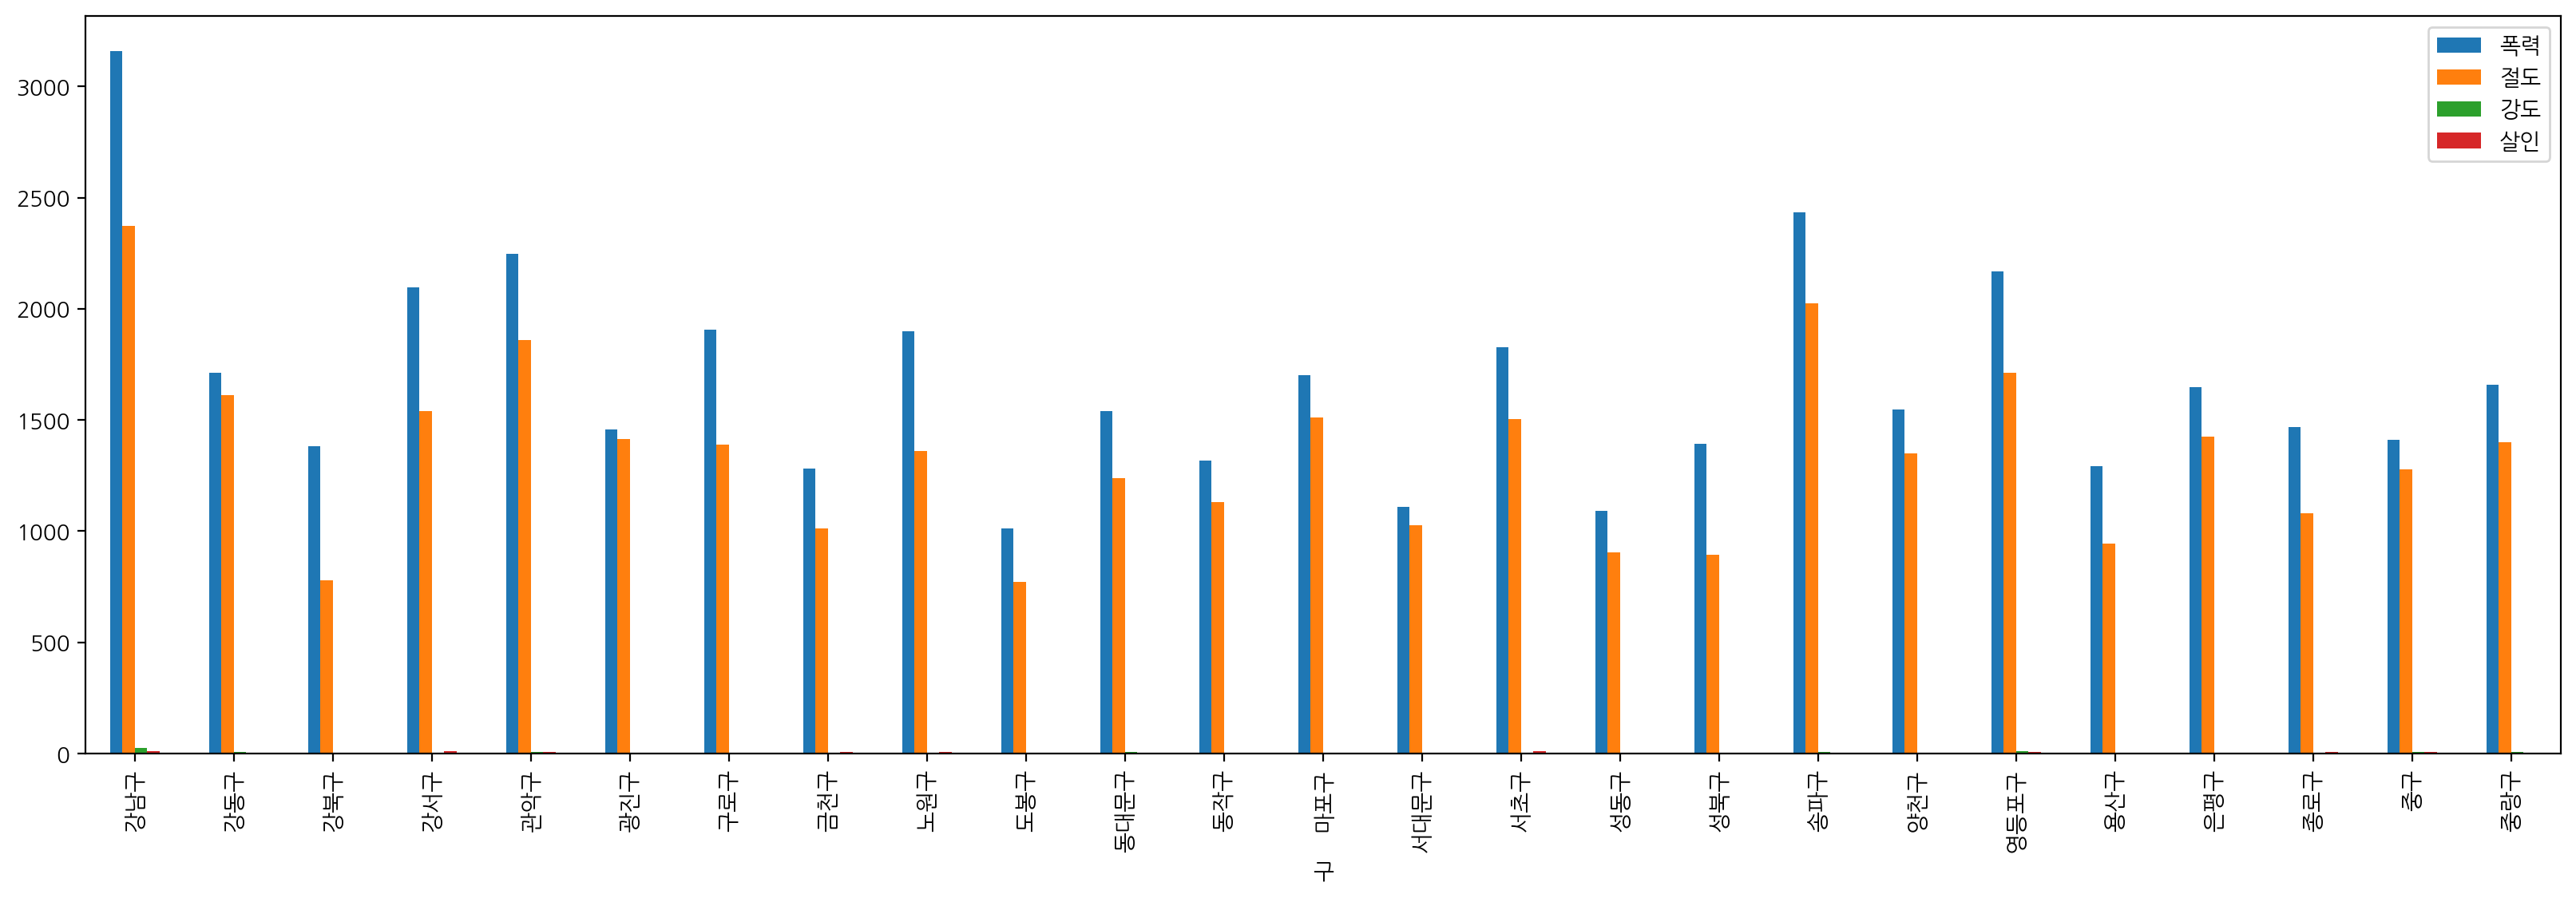

In [38]:
# 구별 5대 범죄 사건 시각화
# 폭력 절도 사건에 비해 강도와 살인은 시각화가 올바르게 표현되지 않는다
ax = crime_gu[['폭력', '절도', '강도', '살인']].plot(kind='bar', figsize=(20, 6))
plt.show()

In [39]:
print('강남구에서 일어난 절도 사건 수', crime_gu.loc['강남구', '절도'])
print('강북구에서 일어난 절도 사건 수', crime_gu.loc['강동구', '절도'])
print('절도 사건 중 제일 큰 값', crime_gu['절도'].max())

강남구에서 일어난 절도 사건 수 2372.0
강북구에서 일어난 절도 사건 수 1612.0
절도 사건 중 제일 큰 값 2372.0


In [40]:
gangnam_theft_norm = np.round(crime_gu.loc['강남구', '절도'] / crime_gu['절도'].max(), 2)
gangbuk_theft_norm = np.round(crime_gu.loc['강북구', '절도'] / crime_gu['절도'].max(), 2)

print('강남구에서 일어난 절도 사건 수(원본)', crime_gu.loc['강남구', '절도'])
print('강남구에서 일어난 절도 사건 수(정규화)', gangnam_theft_norm)
print('='*35)
print('강북구에서 일어난 절도 사건 수(원본)', crime_gu.loc['강북구', '절도'])
print('강북구에서 일어난 절도 사건 수(정규화)', gangbuk_theft_norm)

강남구에서 일어난 절도 사건 수(원본) 2372.0
강남구에서 일어난 절도 사건 수(정규화) 1.0
강북구에서 일어난 절도 사건 수(원본) 777.0
강북구에서 일어난 절도 사건 수(정규화) 0.33


In [41]:
# 정규화 작업
crime_gu_norm = crime_gu[occur_col] / crime_gu[occur_col].max()
crime_gu_norm.head(5)

,강도,살인,성범죄,절도,폭력
구,,,,,
강남구,1.00,1.000000,1.000000,1.000000,1.000000
강동구,0.24,0.250000,0.214533,0.679595,0.542260
강북구,0.04,0.333333,0.235294,0.327572,0.437797
강서구,0.12,0.750000,0.425606,0.649241,0.664134
관악구,0.28,0.666667,0.555363,0.784148,0.711618


In [42]:
# 새로운 crime_gu_norm 컬럼에 기존 검거율 컬럼 추가
crime_gu_norm[arrest_rate] = crime_gu[arrest_rate]
crime_gu_norm.head(5)

,강도,살인,성범죄,절도,폭력,강도검거율,살인검거율,성범죄검거율,절도검거율,폭력검거율
구,,,,,,,,,,
강남구,1.00,1.000000,1.000000,1.000000,1.000000,92.00,91.67,78.55,48.90,87.02
강동구,0.24,0.250000,0.214533,0.679595,0.542260,100.00,100.00,83.06,55.15,85.29
강북구,0.04,0.333333,0.235294,0.327572,0.437797,100.00,100.00,84.56,69.11,90.74
강서구,0.12,0.750000,0.425606,0.649241,0.664134,100.00,77.78,76.42,59.81,91.75
관악구,0.28,0.666667,0.555363,0.784148,0.711618,85.71,50.00,83.80,49.95,85.68


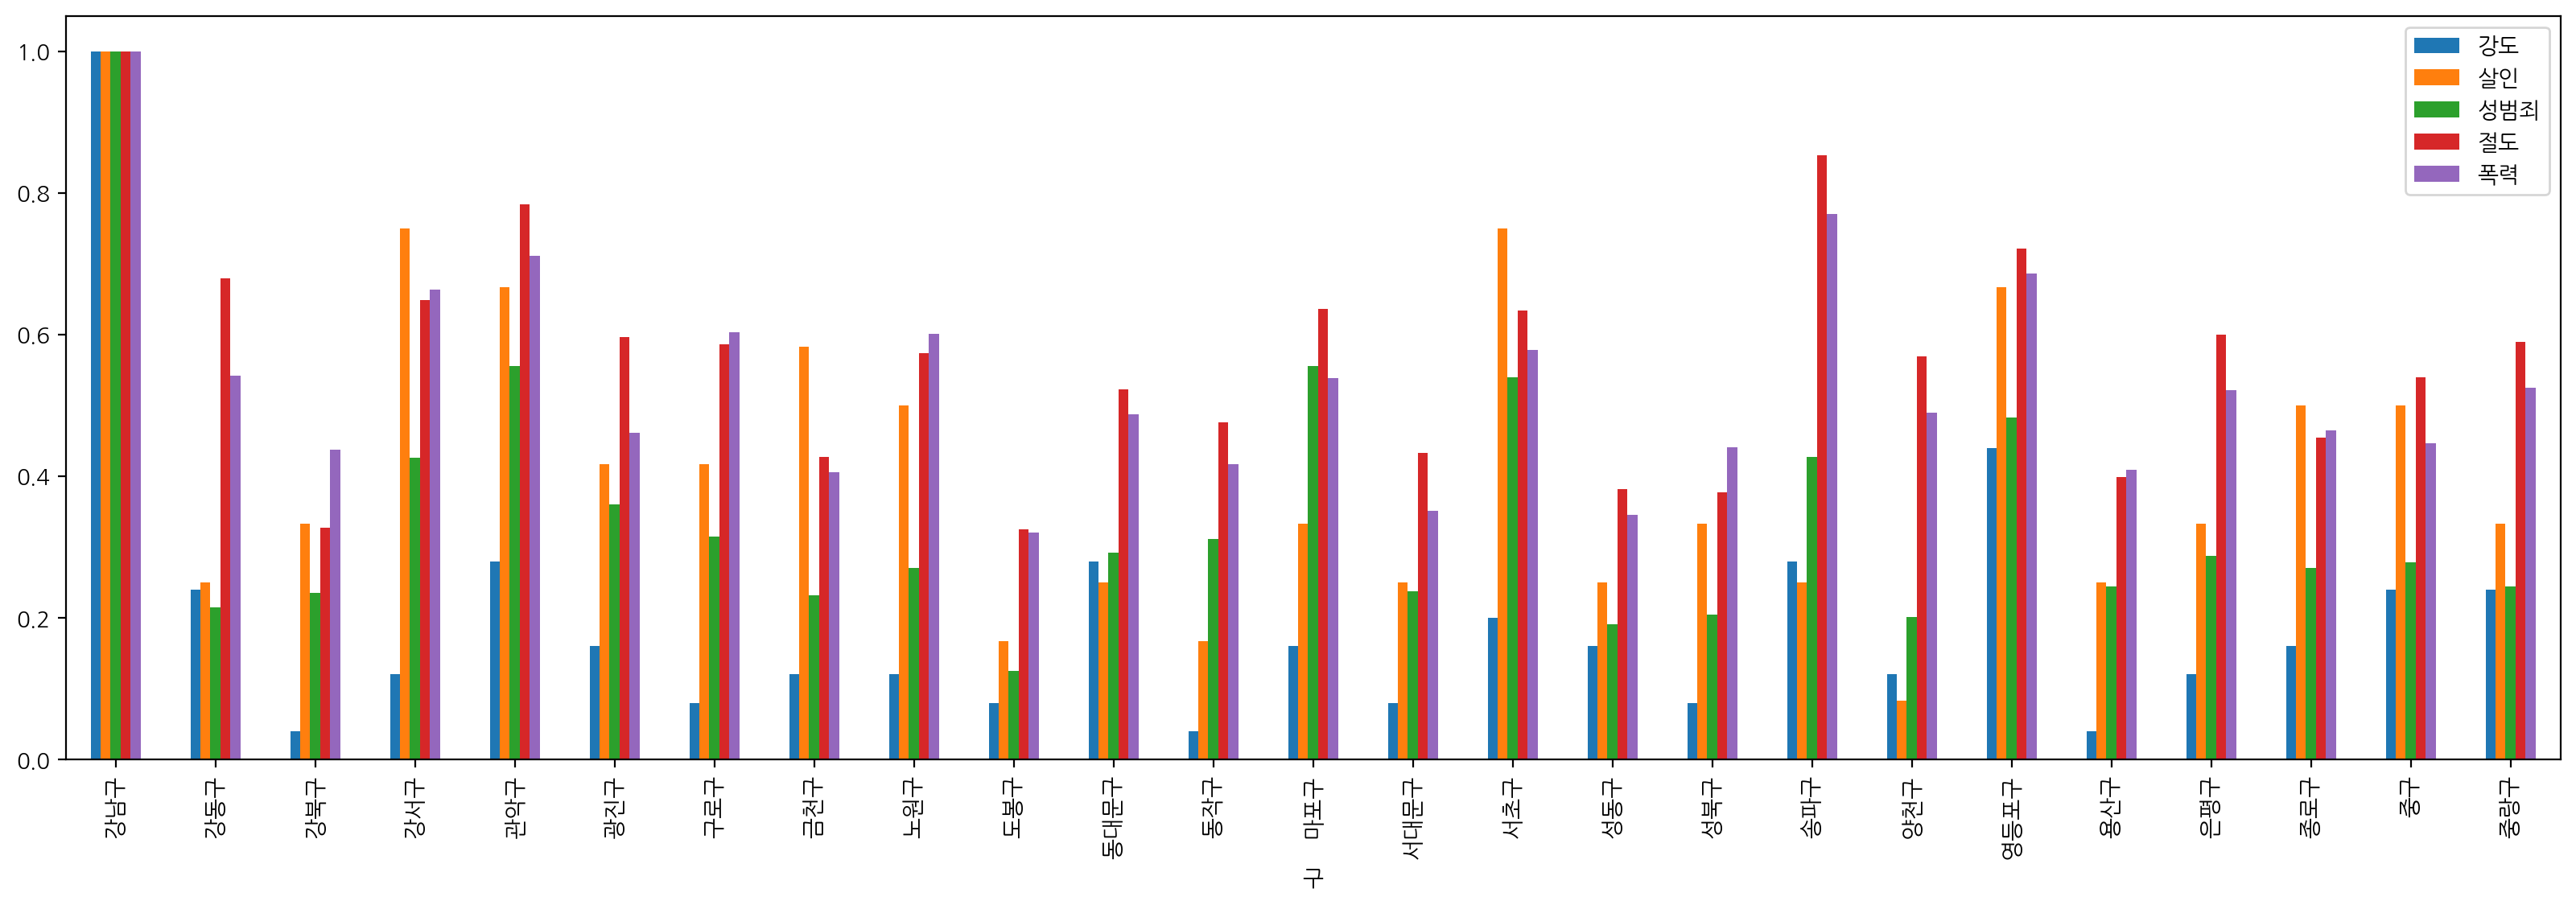

In [43]:
# 정규화 후 다시 구별 5대 범죄 시각화
ax = crime_gu_norm[occur_col].plot(kind='bar', figsize=(20, 6))
plt.show()

### **범죄, 검거 평균 컬럼 생성**

In [44]:
# 1. 강남구에서 일어난 5대 범죄(강도, 살인, 성범죄, 절도 폭력) 선택
crime_gu_norm[occur_col].loc['강북구']

강도     0.040000
살인     0.333333
성범죄    0.235294
절도     0.327572
폭력     0.437797
Name: 강북구, dtype: float64

In [45]:
# 2. 강남구에서 일어난 강도, 살인, 성범죄, 절도, 폭력 사건 더하기
crime_gu_norm[occur_col].loc['강북구'].sum()

1.373995891587731

In [46]:
# 3. 5로 나누기
crime_gu_norm[occur_col].loc['강북구'].sum() / len(crime_gu_norm[occur_col].loc['강북구'])

0.2747991783175462

In [47]:
# 정규화된 5대 범죄 평균값
gangbuk_crime_sum = crime_gu_norm[occur_col].loc['강북구'].sum()
gangbuk_crime_len = len(crime_gu_norm[occur_col].loc['강북구'])
gangbuk_crime_mean = np.round(gangbuk_crime_sum / gangbuk_crime_len, 2)
print(gangbuk_crime_mean)

0.27


In [48]:
# 범죄 평균 컬럼 생성
crime_gu_norm['범죄평균'] = np.mean(crime_gu_norm[occur_col], axis=1)  # numpy axis=1 행, axis=0 열

In [49]:
# 검거평균 컬럼 생성
crime_gu_norm['검거평균'] = np.mean(crime_gu_norm[arrest_rate], axis=1)

In [50]:
crime_gu_norm.head(5)

,강도,살인,성범죄,절도,폭력,강도검거율,살인검거율,성범죄검거율,절도검거율,폭력검거율,범죄평균,검거평균
구,,,,,,,,,,,,
강남구,1.00,1.000000,1.000000,1.000000,1.000000,92.00,91.67,78.55,48.90,87.02,1.000000,79.628
강동구,0.24,0.250000,0.214533,0.679595,0.542260,100.00,100.00,83.06,55.15,85.29,0.385278,84.700
강북구,0.04,0.333333,0.235294,0.327572,0.437797,100.00,100.00,84.56,69.11,90.74,0.274799,88.882
강서구,0.12,0.750000,0.425606,0.649241,0.664134,100.00,77.78,76.42,59.81,91.75,0.521796,81.152
관악구,0.28,0.666667,0.555363,0.784148,0.711618,85.71,50.00,83.80,49.95,85.68,0.599559,71.028


In [51]:
# 범죄 평균치로 정렬했을 때, 서울시에서 범죄가 많이 일어나는 구는?
crime_gu_norm['범죄평균'].sort_values(ascending=False).head()

구
강남구     1.000000
관악구     0.599559
영등포구    0.599546
서초구     0.540356
강서구     0.521796
Name: 범죄평균, dtype: float64

In [52]:
# 검거 평균치로 정렬했을 때, 서울시에서 범죄 검거율이 높은 구는 어디?
crime_gu_norm['검거평균'].sort_values(ascending=False).head()

구
강북구     88.882
중랑구     85.908
은평구     85.304
동대문구    84.844
서대문구    84.820
Name: 검거평균, dtype: float64

### **데이터 저장**

In [ ]:
# 데이터 저장
crime_gu_norm.to_csv('crime_gu_norm_2021.csv', encoding='utf-8')

In [54]:
# 데이터 불러오기
# 첫 번째 컬럼을 인덱스로 설정
occur_col = ['강도', '살인', '성범죄', '절도', '폭력']
crime_gu_norm = pd.read_csv('.\\crime_gu_norm_2021.csv', index_col=0)
crime_gu_norm.head()

,강도,살인,성범죄,절도,폭력,강도검거율,살인검거율,성범죄검거율,절도검거율,폭력검거율,범죄평균,검거평균
구,,,,,,,,,,,,
강남구,1.00,1.000000,1.000000,1.000000,1.000000,92.00,91.67,78.55,48.90,87.02,1.000000,79.628
강동구,0.24,0.250000,0.214533,0.679595,0.542260,100.00,100.00,83.06,55.15,85.29,0.385278,84.700
강북구,0.04,0.333333,0.235294,0.327572,0.437797,100.00,100.00,84.56,69.11,90.74,0.274799,88.882
강서구,0.12,0.750000,0.425606,0.649241,0.664134,100.00,77.78,76.42,59.81,91.75,0.521796,81.152
관악구,0.28,0.666667,0.555363,0.784148,0.711618,85.71,50.00,83.80,49.95,85.68,0.599559,71.028


## **데이터 분석**

### **기본 그래프 시각화**
- 박스플롯(Boxplot)
- 막대 그래프(Bar), 누적 막대 그래프(Stacked Bar)
- 히트맵(heatmap)

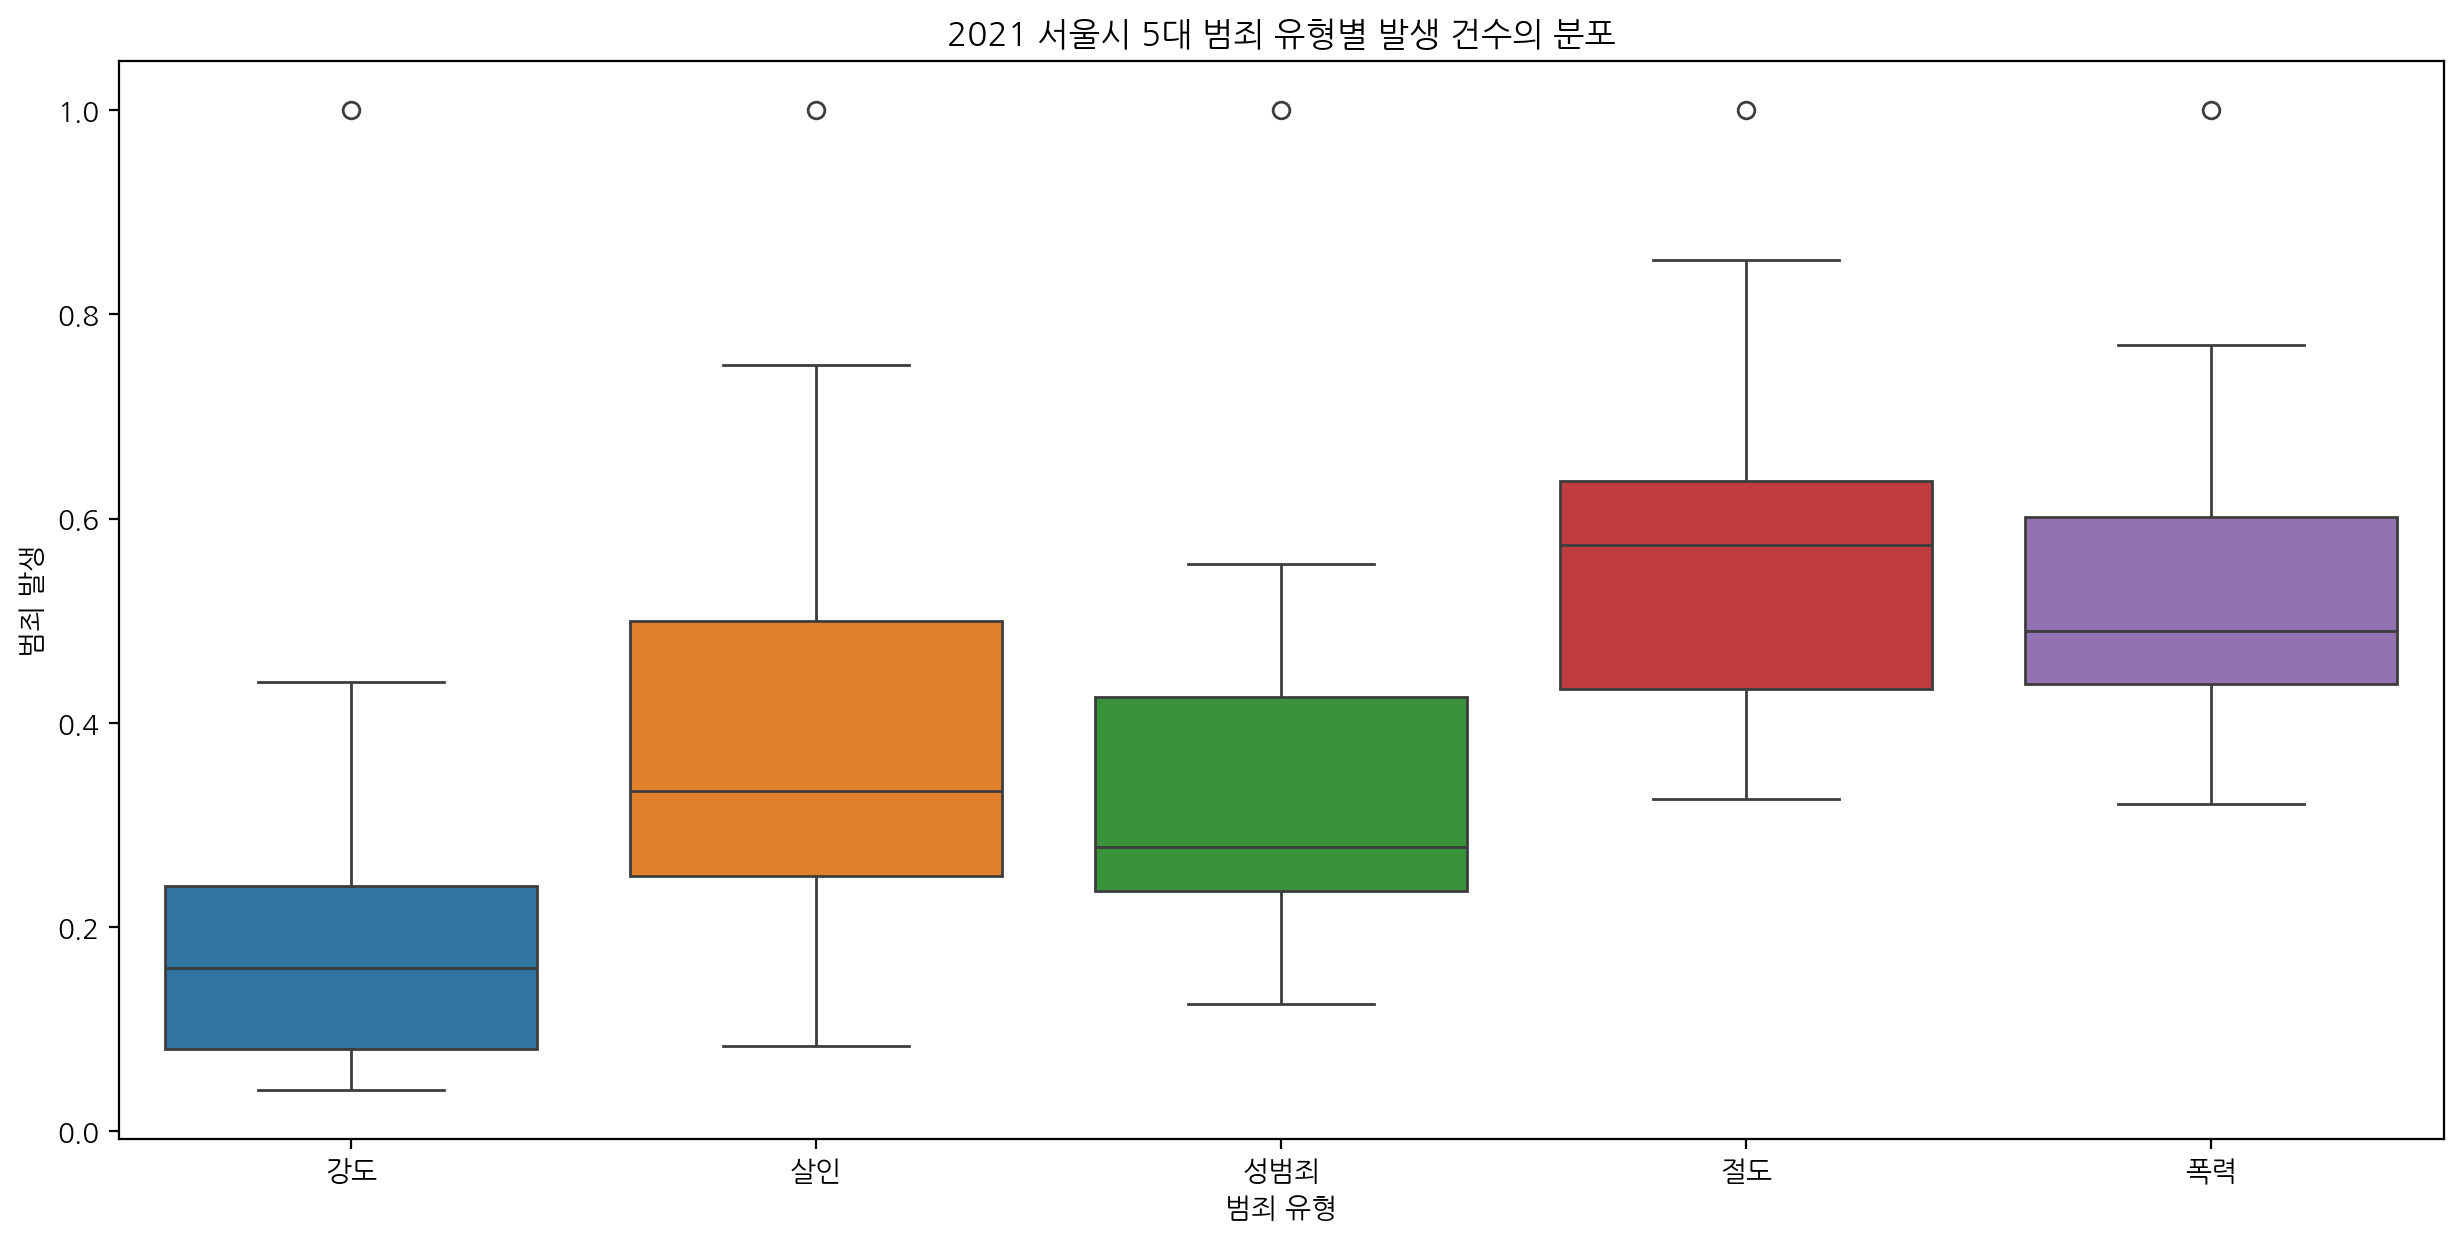

In [57]:
# Box plot
fig, ax = plt.subplots(figsize=(15, 7))

sns.boxplot(data=crime_gu_norm[occur_col])

plt.title('2021 서울시 5대 범죄 유형별 발생 건수의 분포')
plt.ylabel('범죄 발생')
plt.xlabel('범죄 유형')

plt.show()

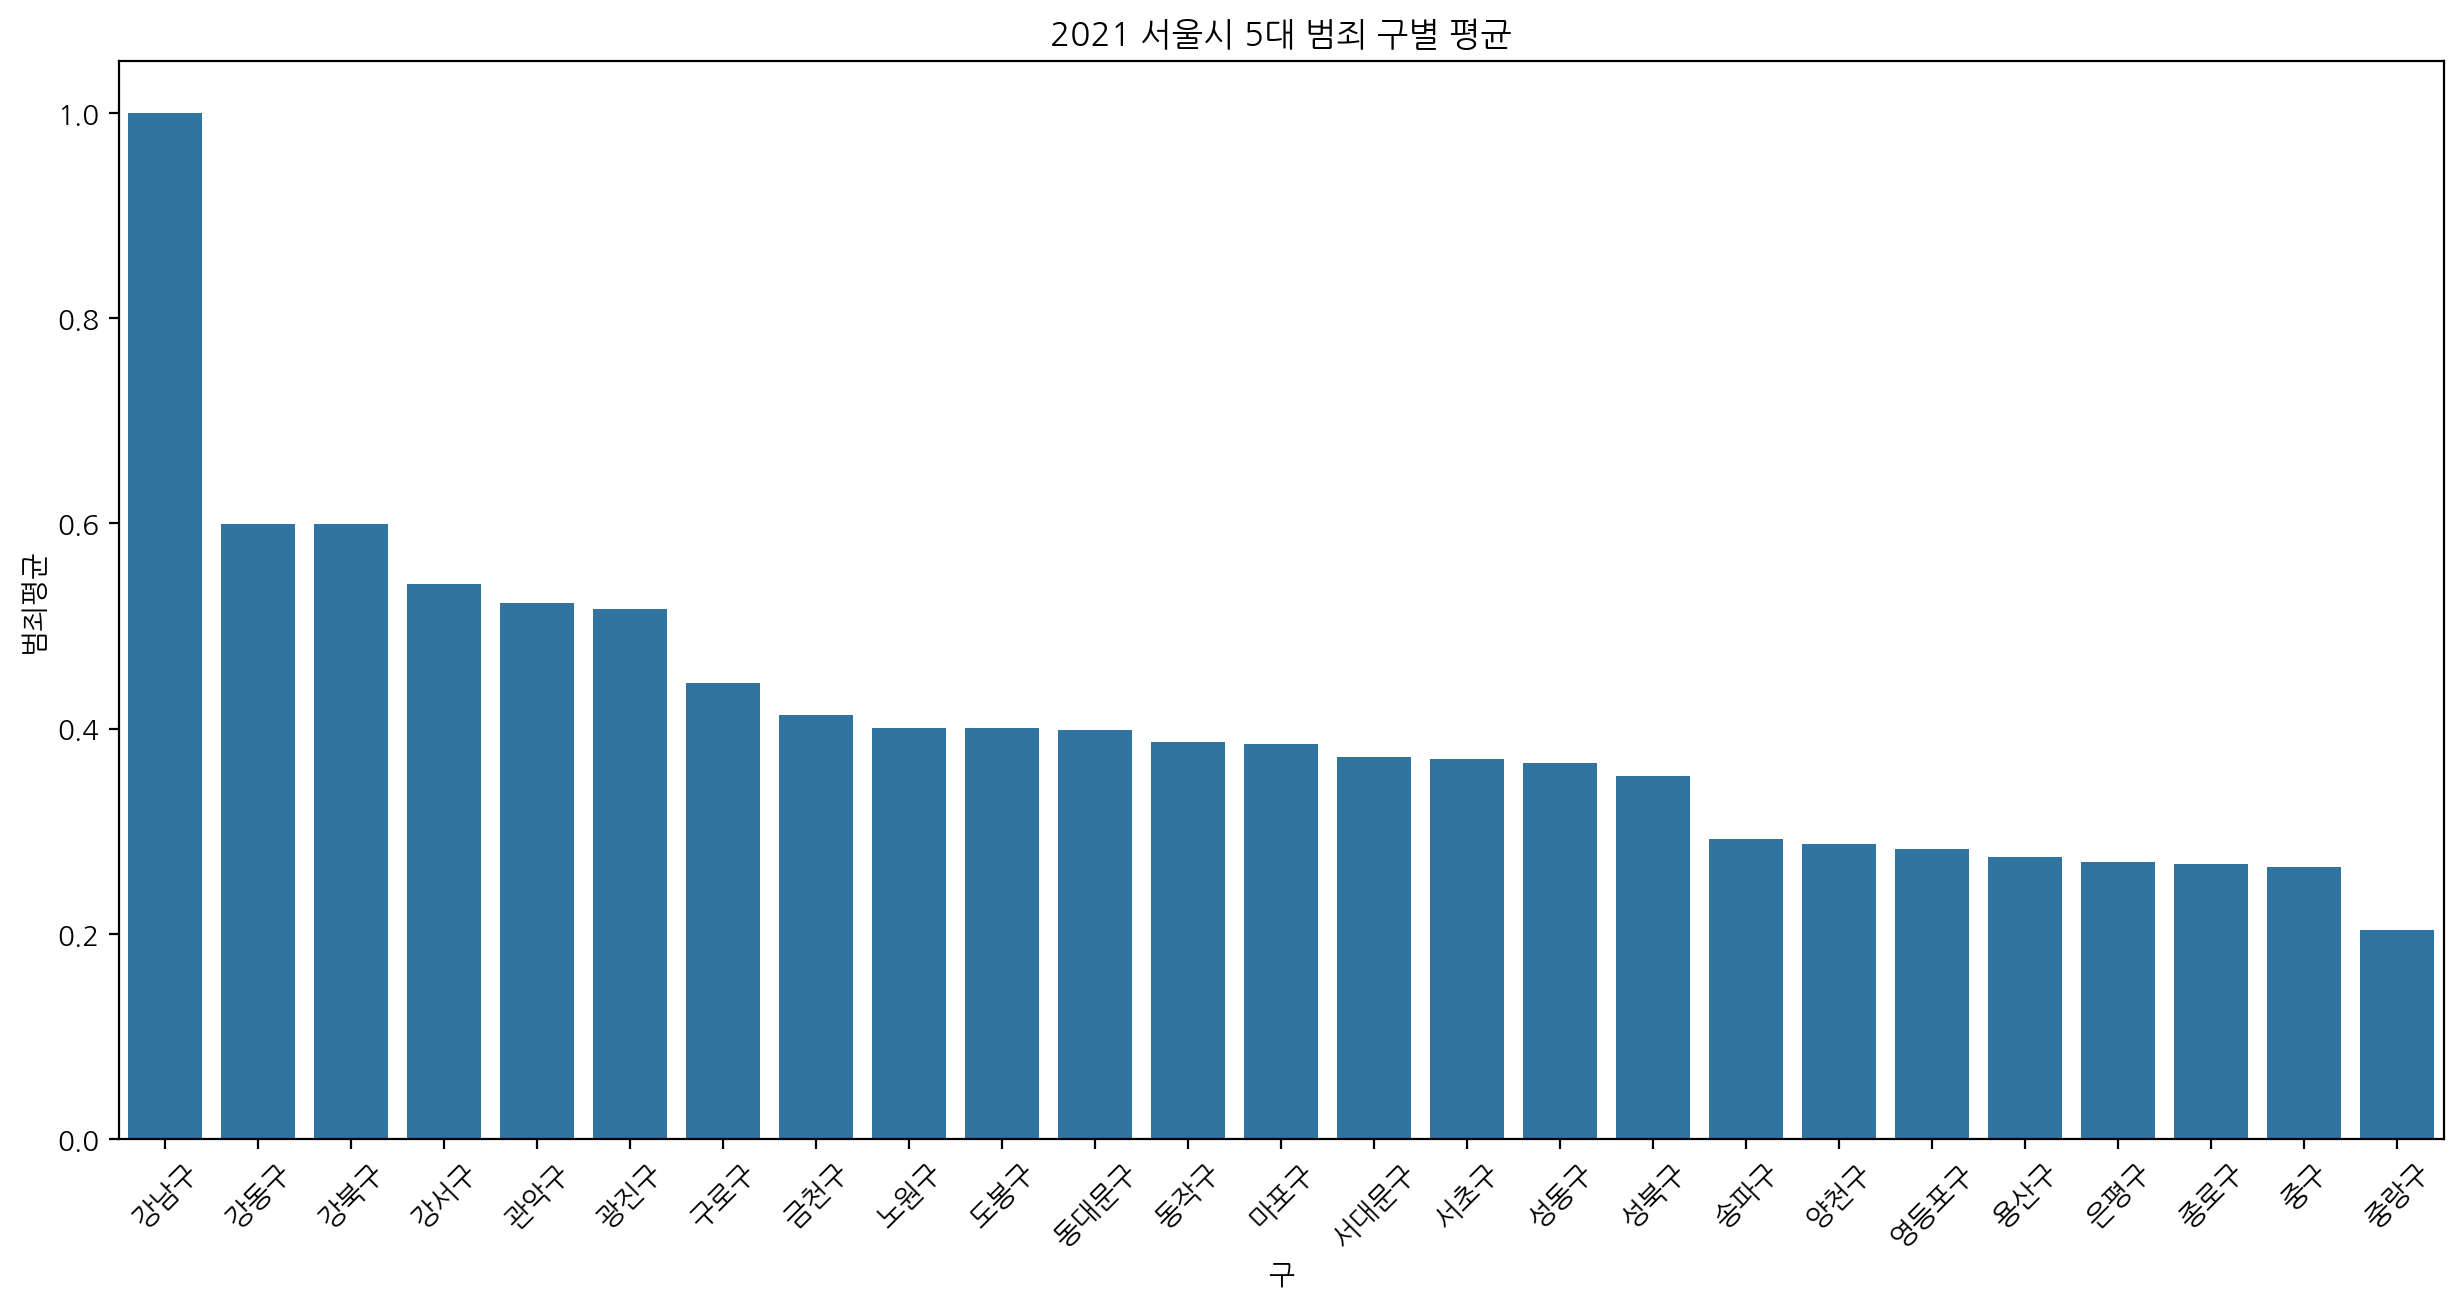

In [59]:
# Bar plot
fig, ax = plt.subplots(figsize=(15, 7))

sns.barplot(x=crime_gu_norm.index,
            y='범죄평균',
            data=crime_gu_norm.sort_values(by='범죄평균', ascending=False))

plt.title('2021 서울시 5대 범죄 구별 평균')
plt.xticks(rotation=45)

plt.show()

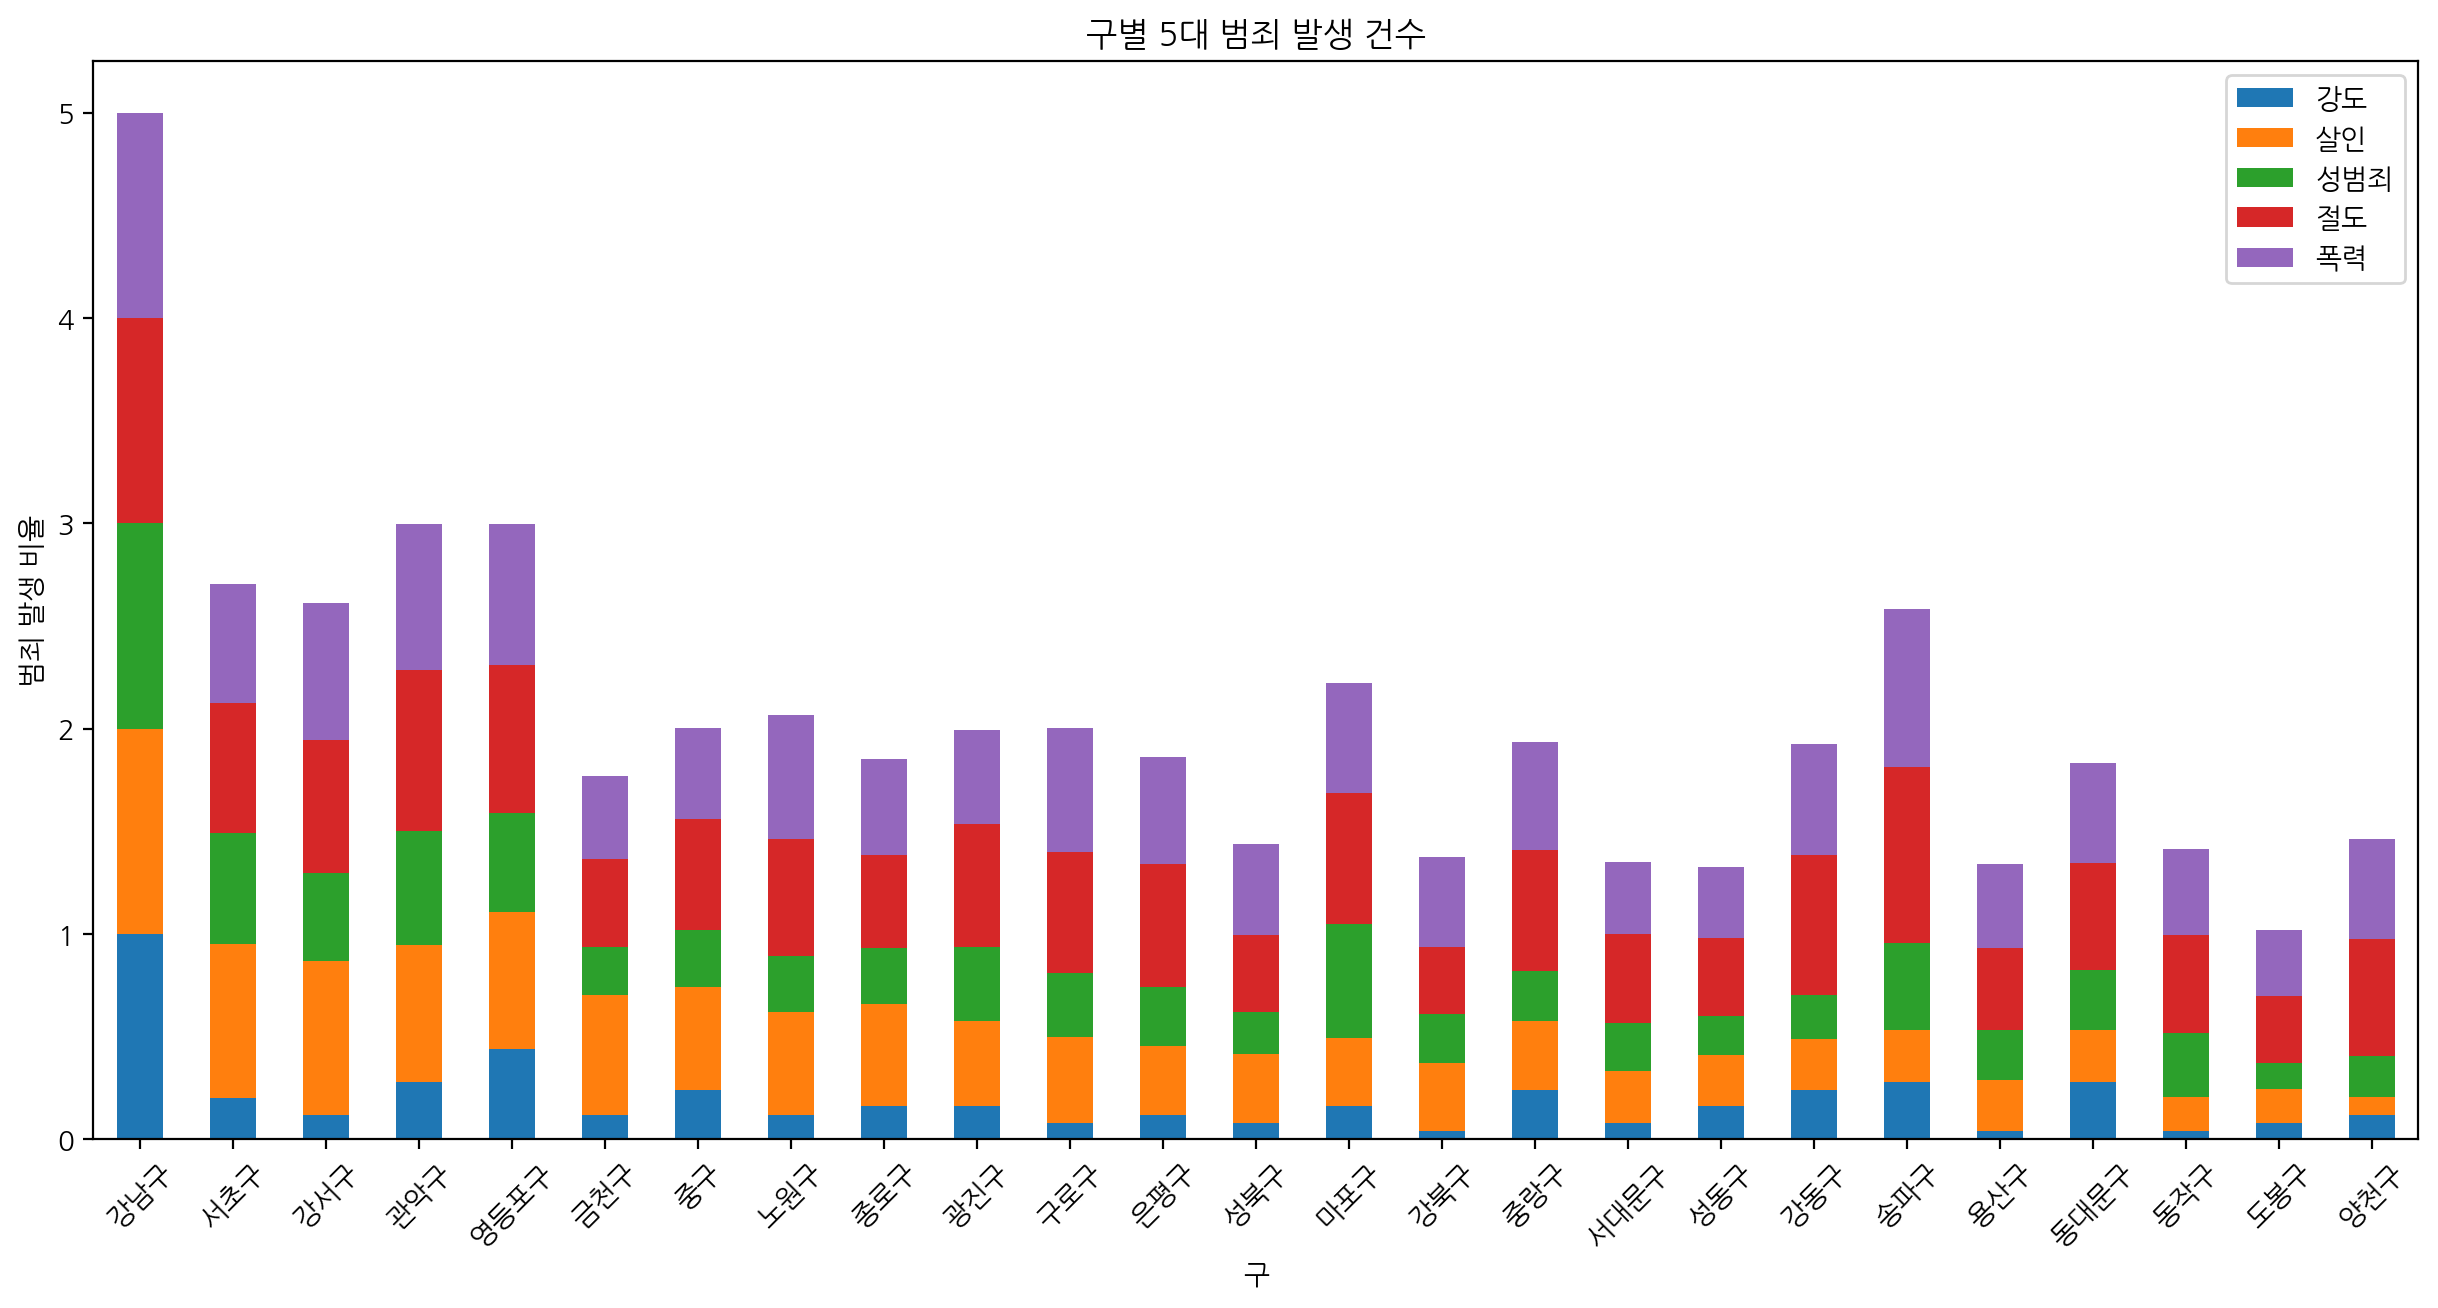

In [63]:
# Stacked Bar plot
stacked_crime_gu = crime_gu_norm[occur_col].sort_values(by='살인', ascending=False)
stacked_crime_gu.plot(kind='bar', stacked=True, figsize=(15, 7))

plt.title('구별 5대 범죄 발생 건수')
plt.ylabel('범죄 발생 비율')
plt.xlabel('구')
plt.xticks(rotation=45)

plt.show()

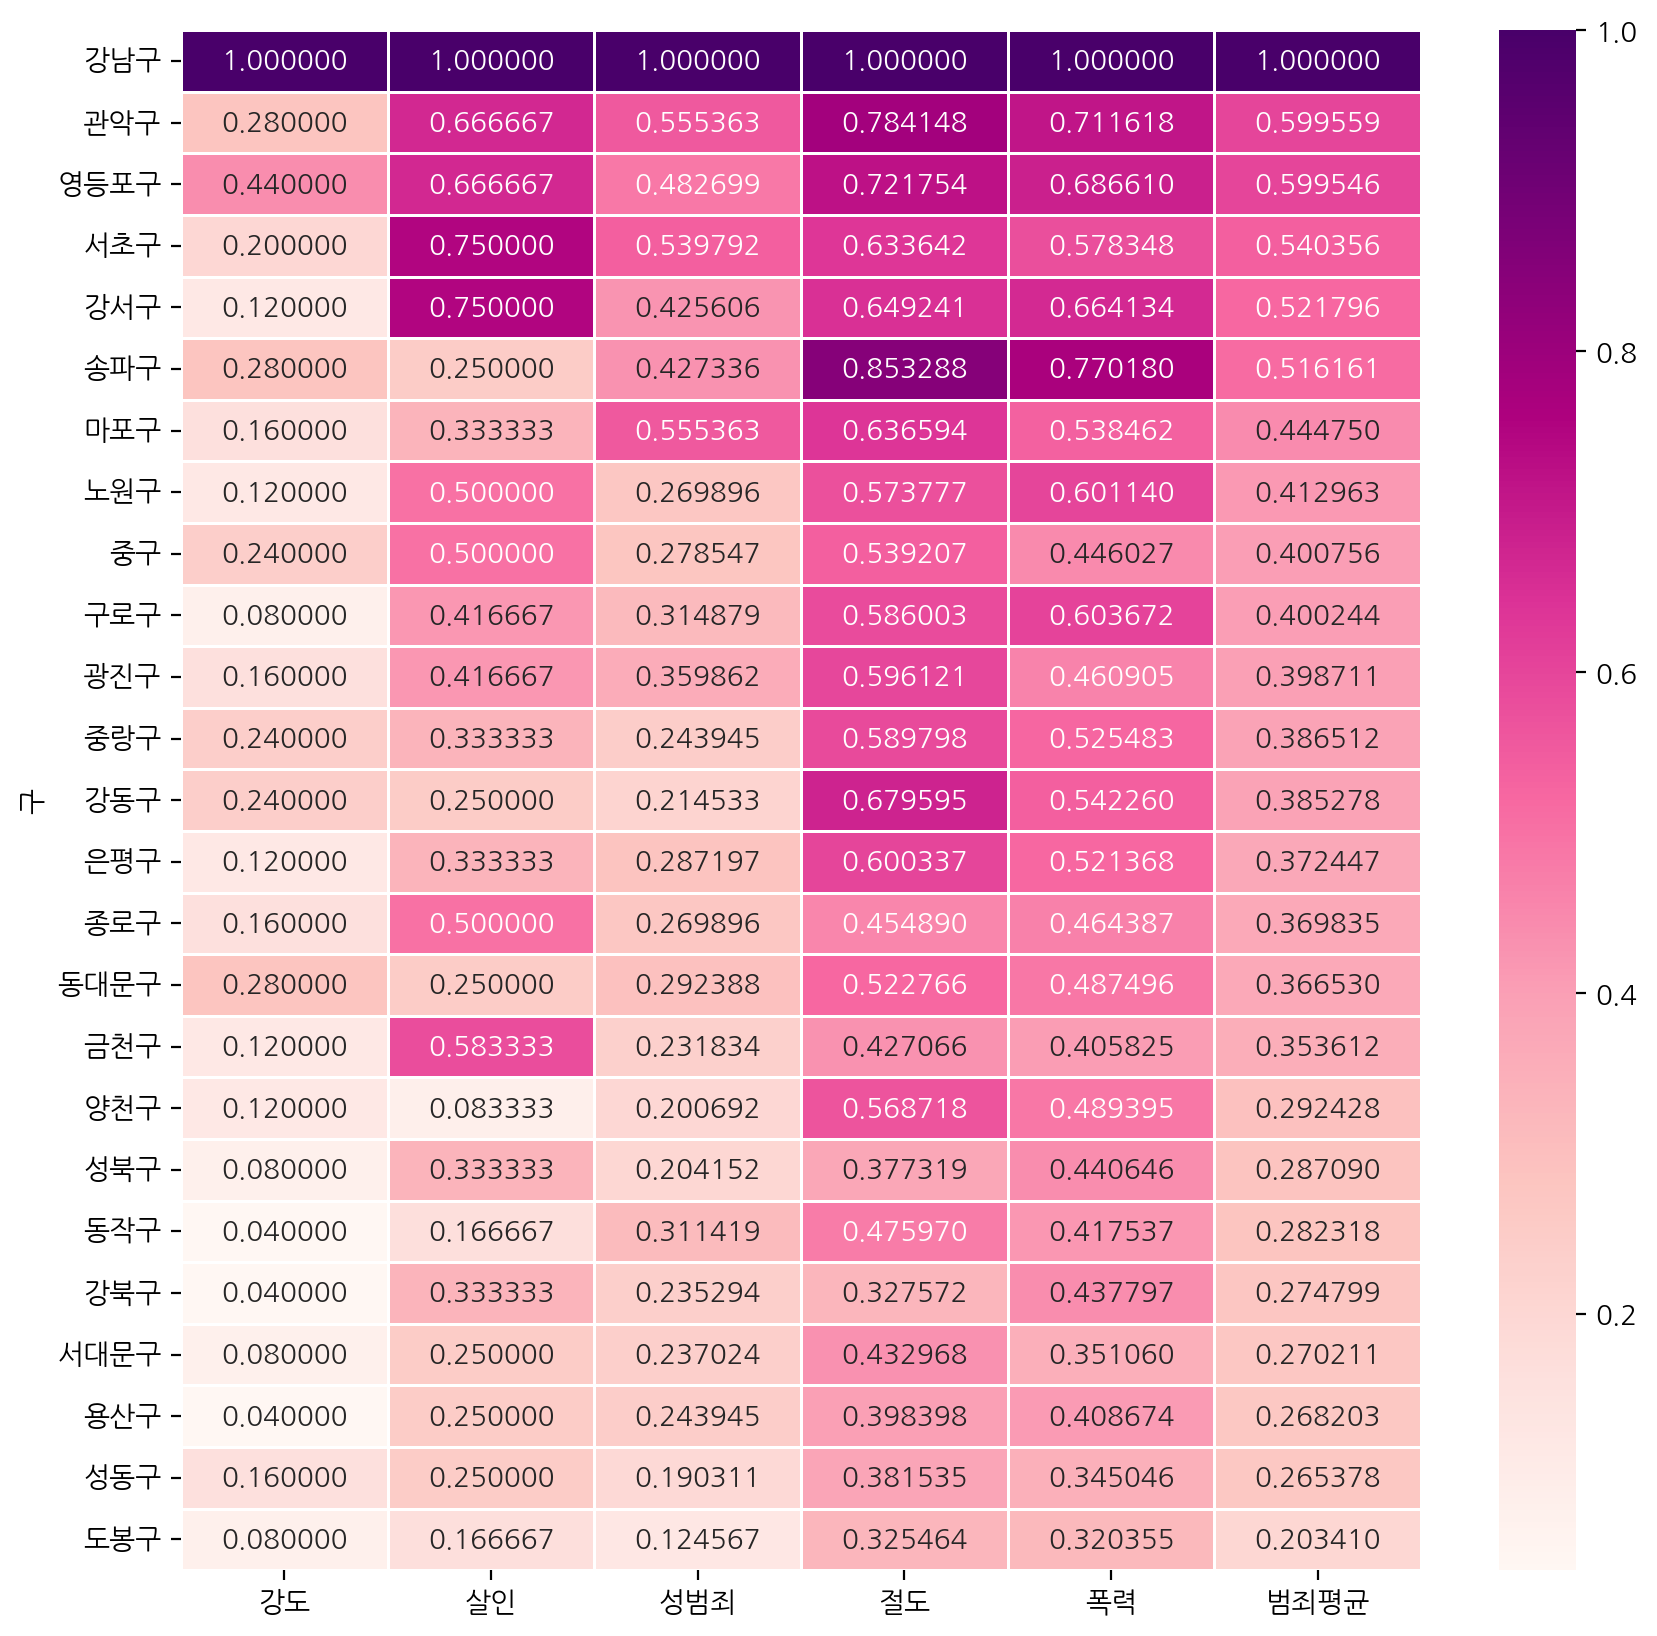

In [65]:
# Heatmap
target_col = ['강도', '살인', '성범죄', '절도', '폭력', '범죄평균']
crime_gu_norm_sort = crime_gu_norm[target_col].sort_values(by='범죄평균', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(crime_gu_norm_sort,
            annot=True,
            fmt='f',
            linewidths=.5,
            cmap='RdPu')

plt.show()

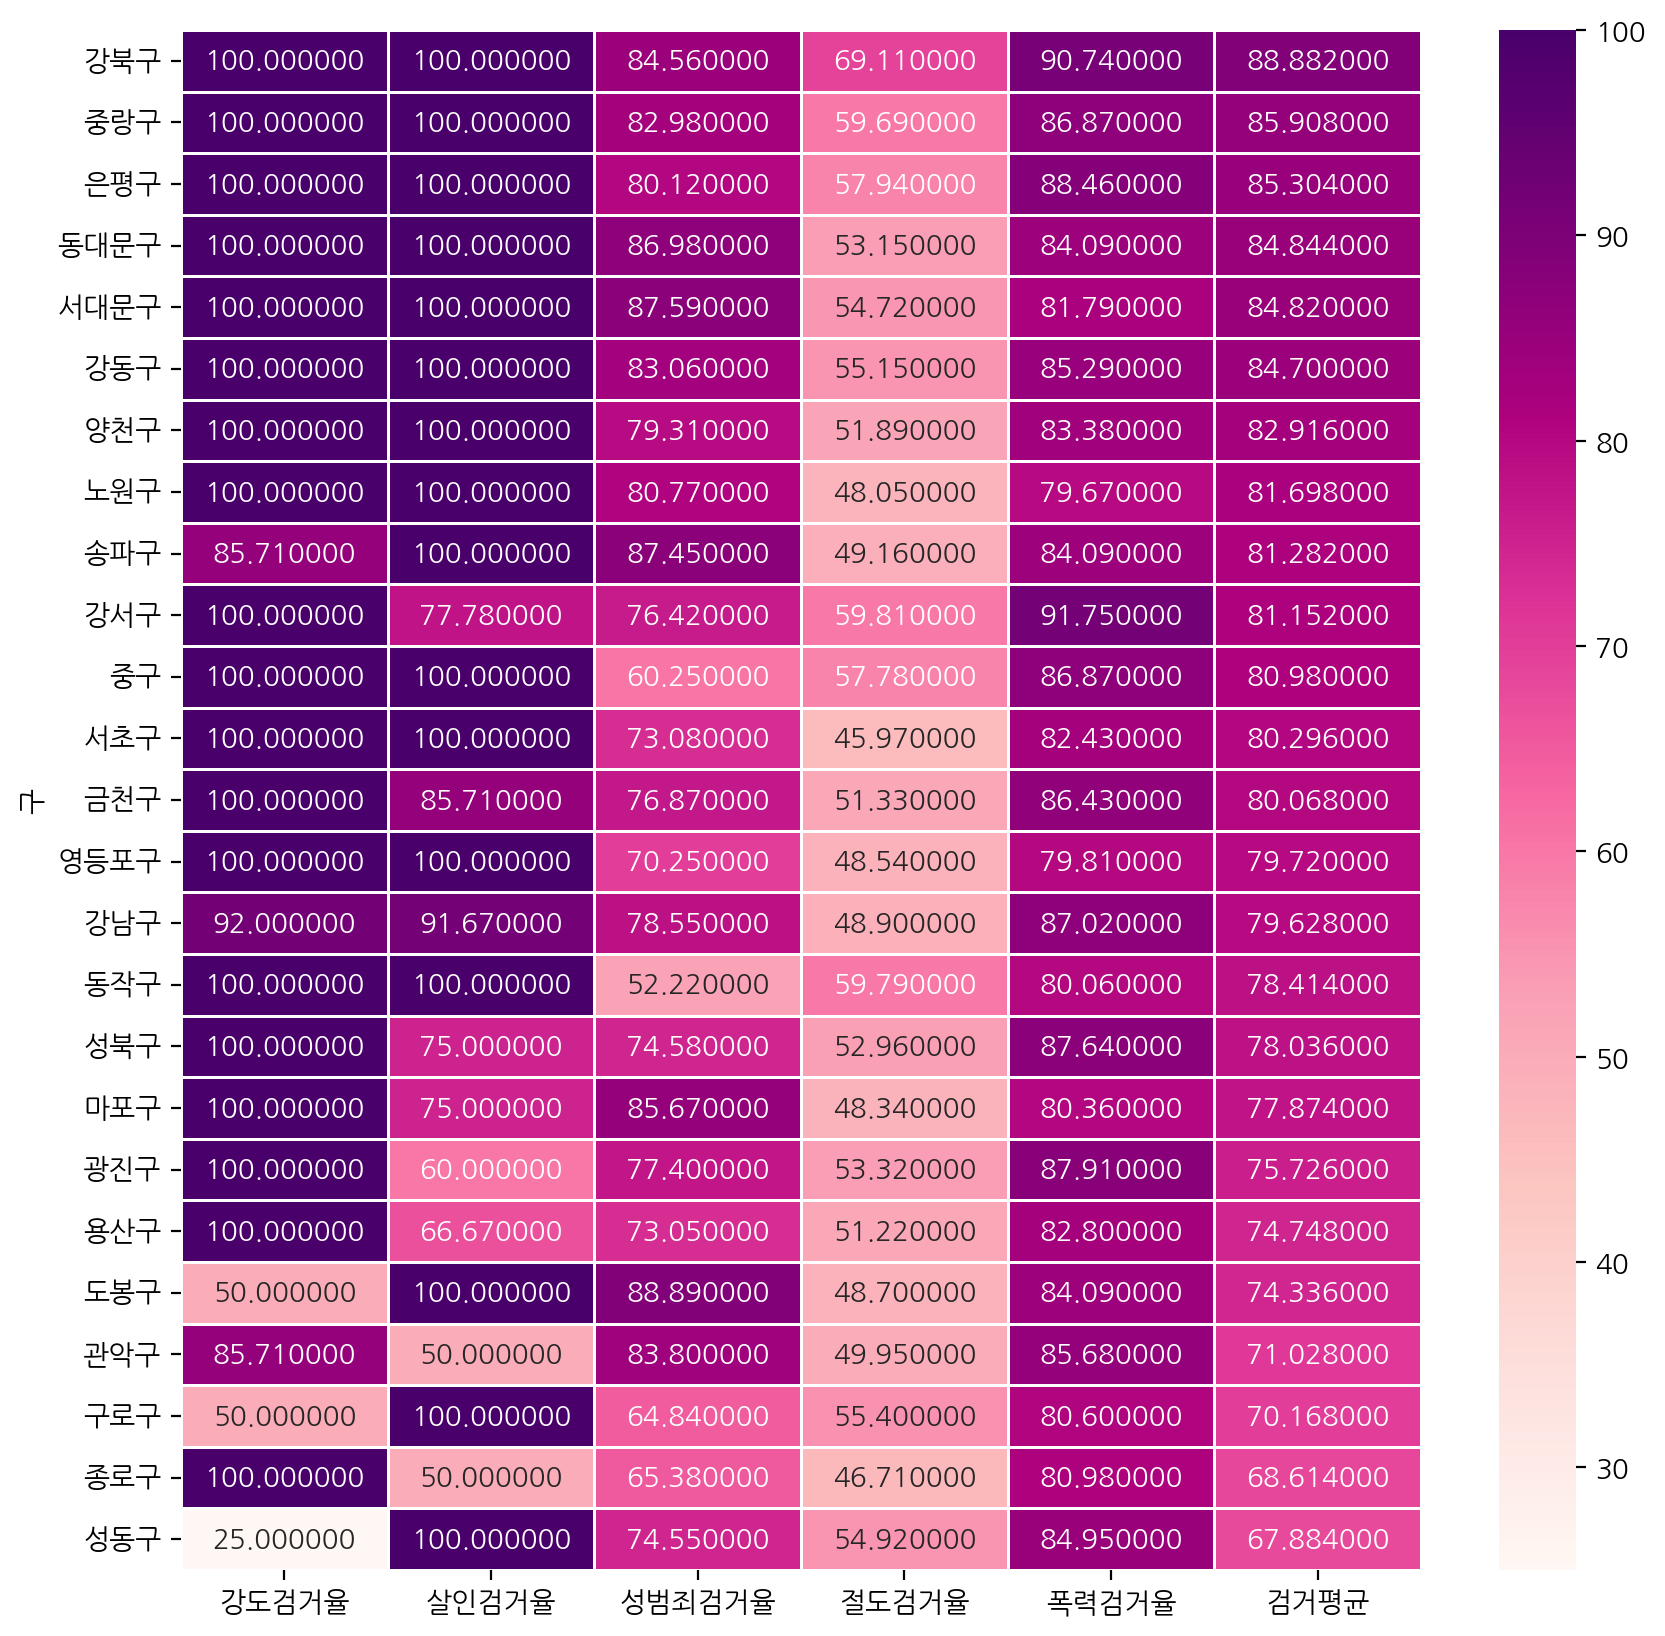

In [66]:
target_col = ['강도검거율', '살인검거율', '성범죄검거율', '절도검거율', '폭력검거율', '검거평균']
crime_gu_norm_sort = crime_gu_norm.sort_values(by='검거평균', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(crime_gu_norm_sort[target_col],
            annot=True,
            fmt='f',
            linewidths=.5,
            cmap='RdPu')

plt.show()

### **지도 시각화**

In [70]:
import folium

# 맵 생성
my_map = folium.Map(location=[37.5502, 126.982], zoom_start=11)

# 마커 추가
folium.Marker(location=[37.5502, 126.982], tooltip='서울').add_to(my_map)

# 원 추가
folium.Circle(location=[37.5502, 126.982], radius=1000, color='red').add_to(my_map)

my_map

#### **folium.Map()**

In [71]:
my_map = folium.Map(location=[37.495419, 127.033066], zoom_start=12)

my_map

#### **folium.Marker()**

In [73]:
gangnam_loc = [37.495419, 127.033066]

my_map = folium.Map(location=gangnam_loc, zoom_start=13)

# Marker
# 강남역 12번 출구 쏘카존
folium.Marker(location=[37.495419, 127.033066], tooltip='쏘카존').add_to(my_map)

my_map

#### **folium.Icon()**

In [82]:
gangnam_loc = [37.495419, 127.033066]

my_map = folium.Map(location=gangnam_loc, zoom_start=13)

# Marker
# 강남역 12번 출구 쏘카존
folium.Marker(location=[37.495419, 127.033066], tooltip='쏘카존').add_to(my_map)

# Icon
# 역삼역 2호선
folium.Marker(
    location=[37.499615, 127.029594],
    tooltip='역삼역',
    icon=folium.Icon(color='black', icon='info-sign')
    ).add_to(my_map)

# 기술 평가원
folium.Marker(
    location=[37.503324, 127.043816],  # 강남역 12번 출구 쏘카존
    popup='쏘카존',
    tooltip='차를 타고 떠날까요',
    icon=folium.Icon(
        color='red',
        icon_color='blue',
        icon='fa-house',
        prefix='fa'
    )
).add_to(my_map)

# icon custom 
folium.Marker(
    location=[37.503822, 127.024277],  # 강남 교보문고
    popup='교보문고',
    tooltip='icon custom',
    icon=folium.Icon(
        color='lightblue',
        icon_color='white',
        icon='glyphicon glyphicon-thumbs-up',
        angle=50,
        prefix='glyphicon'
    )   
).add_to(my_map)

my_map

#### **folium.Circle()**

In [88]:
gangnam_loc = [37.495419, 127.033066]

my_map = folium.Map(location=gangnam_loc, zoom_start=13)

# Circle
folium.Circle(
    location=[37.501881, 127.039201],
    radius=1000,
    color='lightblue',
    fill_color='#eb9e34',
    tooltip='circle tooltip'
).add_to(my_map)

# Circle Marker
folium.CircleMarker(
    location=[37.503007, 127.039301],
    radius=10,
    color='red',
    fill_color='#c634eb',
    tooltip='circlemarker'
).add_to(my_map)

my_map

#### **folium.Choropleth()**

In [89]:
state_data = pd.read_csv('.\\US_Unemployment_Oct2012.csv')
state_data.head()

,State,Unemployment
0,AL,7.1
1,AK,6.8
2,AZ,8.1
3,AR,7.2
4,CA,10.1


In [90]:
state_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Unemployment  50 non-null     float64
dtypes: float64(1), object(1)
memory usage: 932.0+ bytes


In [96]:
my_map = folium.Map(location=[43, -102], zoom_start=3, tiles='Stamen Toner')

# 경계선을 그리는 기능
folium.Choropleth(
    geo_data='.\\us-states.json', # 경계선 좌표값이 담긴 데이터
    data=state_data, # Pandas Series, DataFrame
    columns=['State', 'Unemployment'],
    key_on='feature.id',
    # 꾸미는 옵션
    fill_color='BuPu',
    fill_opacity='0.5', # 0 ~ 1 
    line_opacity='0.2', # 0 ~ 1
    legend_name='Unemployment rate(%)'
).add_to(my_map)

my_map

### **범죄 지도 시각화**

In [104]:
# 서울시에서 일어난 살인 사건 지도 시각화
my_map = folium.Map(
    location=[37.5502, 126.982],
    zoom_start=11
)

folium.Choropleth(
    geo_data='.\\skorea_municipalities_geo_simple.json', # 서울시 경계선이 담긴 지리 데이터
    data=crime_gu_norm['살인'],
    columns=[crime_gu_norm.index, crime_gu_norm['살인']],
    key_on='feature.id',

    # 꾸미는 옵션
    fill_color='PuRd',
    fill_opacity=0.7,
    line_opacity=1,
    legend_name='정규화된 살인 발생 건수'
).add_to(my_map)

my_map

In [105]:
# 서울시에서 일어난 성범죄 사건 지도 시각화
my_map = folium.Map(
    location=[37.5502, 126.982],
    zoom_start=11
)

folium.Choropleth(
    geo_data='.\\skorea_municipalities_geo_simple.json', # 서울시 경계선이 담긴 지리 데이터
    data=crime_gu_norm['성범죄'],
    columns=[crime_gu_norm.index, crime_gu_norm['성범죄']],
    key_on='feature.id',

    # 꾸미는 옵션
    fill_color='PuRd',
    fill_opacity=0.7,
    line_opacity=1,
    legend_name='정규화된 성범죄 발생 건수'
).add_to(my_map)

my_map